**[LINK TO MY RECORDINGS](https://drive.google.com/drive/folders/1SVtiKQZoM-KaEmiy-Ycj2yrUS4z3GkB_?usp=drive_link)**

**4 LANGUAGES RECORDED BY ME**

NAME: MUHAMMAD UMAR FAROOQ

ID: F2023376310

SECTION: D1 (MACHINE LEARINING)

In [ ]:
!pip install librosa soundfile

In [33]:
import numpy as np
import librosa
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
DRIVE_FOLDERS = [
    '/content/drive/MyDrive/Recordings ML Assignment 3/Recordings-026',
    '/content/drive/MyDrive/Recordings ML Assignment 3/Recordings-310',
    '/content/drive/MyDrive/Recordings ML Assignment 3/Recordings-407',
    '/content/drive/MyDrive/Recordings ML Assignment 3/Recordings-060',
    '/content/drive/MyDrive/Recordings ML Assignment 3/Recordings-349',
    '/content/drive/MyDrive/Recordings ML Assignment 3/Recordings-075'
]

audio_files = []
for folder in DRIVE_FOLDERS:
    for f in os.listdir(folder):
        if f.endswith('.wav'):
            audio_files.append(os.path.join(folder, f))

print(f"Total audio files found: {len(audio_files)}")

Total audio files found: 602


In [69]:
def extract_mfcc_enhanced(file_path, n_mfcc=13):
    try:
        audio, sr = librosa.load(file_path, sr=16000)
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)

        mfcc_mean = np.mean(mfccs, axis=1)
        mfcc_std = np.std(mfccs, axis=1)
        mfcc_max = np.max(mfccs, axis=1)
        mfcc_min = np.min(mfccs, axis=1)

        features = np.concatenate([mfcc_mean, mfcc_std, mfcc_max, mfcc_min])
        return features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [46]:
def add_feature_noise(X, noise_level=0.01):
    """Add small Gaussian noise to features for regularization"""
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

In [70]:
def load_dataset(folder_paths):
    """
    Load all audio files and extract features
    Returns: X (features), y (labels), filenames
    """
    features = []
    labels = []
    filenames = []

    label_map = {'ur': 0, 'en': 1, 'ue': 2, 'tr': 3}

    if isinstance(folder_paths, str):
        folder_paths = [folder_paths]

    for folder_path in folder_paths:
        print(f"Processing folder: {folder_path}")
        file_count = 0

        for filename in os.listdir(folder_path):
            if not filename.endswith('.wav'):
                continue

            lang_code = filename.split('-')[0]

            if lang_code not in label_map:
                print(f"Unknown language code in {filename}, skipping...")
                continue

            file_path = os.path.join(folder_path, filename)

            mfcc_features = extract_mfcc_enhanced(file_path)

            if mfcc_features is not None:
                features.append(mfcc_features)
                labels.append(label_map[lang_code])
                filenames.append(filename)
                file_count += 1

        print(f"  Loaded {file_count} files from this folder")

    return np.array(features), np.array(labels), filenames

print("Extracting enhanced features from audio files...")

X, y, file_list = load_dataset(DRIVE_FOLDERS)

print(f"\nDataset loaded successfully!")
print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Label distribution:")
unique_labels = np.unique(y)
for label in unique_labels:
    label_names = {0: 'Urdu', 1: 'English', 2: 'Mixed', 3: 'Turkish'}
    print(f"  {label_names.get(label, f'Class {label}')} ({label}): {np.sum(y == label)}")

Extracting enhanced features from audio files...
Processing folder: /content/drive/MyDrive/Recordings ML Assignment 3/Recordings-026
  Loaded 84 files from this folder
Processing folder: /content/drive/MyDrive/Recordings ML Assignment 3/Recordings-310
  Loaded 184 files from this folder
Processing folder: /content/drive/MyDrive/Recordings ML Assignment 3/Recordings-407
  Loaded 84 files from this folder
Processing folder: /content/drive/MyDrive/Recordings ML Assignment 3/Recordings-060
  Loaded 84 files from this folder
Processing folder: /content/drive/MyDrive/Recordings ML Assignment 3/Recordings-349
  Loaded 84 files from this folder
Processing folder: /content/drive/MyDrive/Recordings ML Assignment 3/Recordings-075
  Loaded 82 files from this folder

Dataset loaded successfully!
Feature matrix shape: (602, 52)
Labels shape: (602,)
Label distribution:
  Urdu (0): 178
  English (1): 180
  Mixed (2): 144
  Turkish (3): 100


In [59]:
print("Normalizing features...")
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Add bias term x0 = 1 as the first feature
X_with_bias = np.column_stack([np.ones(X_normalized.shape[0]), X_normalized])
print(f"Feature matrix with bias shape: {X_with_bias.shape}")

Normalizing features...
Feature matrix with bias shape: (602, 53)


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X_with_bias, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
)

print(f"Final train set: {X_train_final.shape[0]}")
print(f"Validation set: {X_val.shape[0]}")

Train set size: 481
Test set size: 121
Final train set: 384
Validation set: 97


In [61]:
class MultinomialLogisticRegression:
    """
    Multinomial Logistic Regression with L2 Regularization
    """

    def __init__(self, learning_rate=0.08, epochs=3000, num_classes=4, lambda_reg=0.02):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.num_classes = num_classes
        self.lambda_reg = lambda_reg
        self.weights = None
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []

    def softmax(self, z):
        """
        Softmax function for multinomial logistic regression
        z: (n_samples, n_classes)
        Returns: probabilities (n_samples, n_classes)
        """
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def cross_entropy_loss(self, y_true, y_pred):
        """
        Cross-entropy loss with L2 regularization for multinomial classification
        """
        n_samples = y_true.shape[0]

        y_one_hot = np.zeros((n_samples, self.num_classes))
        y_one_hot[np.arange(n_samples), y_true] = 1

        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        ce_loss = -np.sum(y_one_hot * np.log(y_pred)) / n_samples

        l2_loss = (self.lambda_reg / 2) * np.sum(self.weights[1:, :] ** 2)

        return ce_loss + l2_loss

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        """
        Train the model using batch gradient descent with L2 regularization
        """
        n_samples, n_features = X_train.shape

        np.random.seed(42)
        self.weights = np.random.randn(n_features, self.num_classes) * 0.01

        y_train_one_hot = np.zeros((n_samples, self.num_classes))
        y_train_one_hot[np.arange(n_samples), y_train] = 1

        for epoch in range(self.epochs):
            X_train_noisy = add_feature_noise(X_train, noise_level=0.01) if epoch % 2 == 0 else X_train
            z = np.dot(X_train_noisy, self.weights)
            y_pred = self.softmax(z)

            train_loss = self.cross_entropy_loss(y_train, y_pred)
            self.train_losses.append(train_loss)

            train_acc = accuracy_score(y_train, np.argmax(y_pred, axis=1))
            self.train_accuracies.append(train_acc)

            gradient = np.dot(X_train.T, (y_pred - y_train_one_hot)) / n_samples

            reg_gradient = self.lambda_reg * self.weights
            reg_gradient[0, :] = 0
            gradient += reg_gradient

            self.weights -= self.learning_rate * gradient

            if X_val is not None and y_val is not None:
                val_pred = self.predict_proba(X_val)
                val_loss = self.cross_entropy_loss(y_val, val_pred)
                self.val_losses.append(val_loss)

                val_acc = accuracy_score(y_val, np.argmax(val_pred, axis=1))
                self.val_accuracies.append(val_acc)

            if (epoch + 1) % 200 == 0:
                if X_val is not None:
                    print(f"Epoch {epoch+1}/{self.epochs} - "
                          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
                          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
                else:
                    print(f"Epoch {epoch+1}/{self.epochs} - "
                          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")

    def predict_proba(self, X):
        """Predict class probabilities"""
        z = np.dot(X, self.weights)
        return self.softmax(z)

    def predict(self, X):
        """Predict class labels"""
        probabilities = self.predict_proba(X)
        return np.argmax(probabilities, axis=1)

In [87]:
print("PART 1: TRAINING MULTINOMIAL LOGISTIC REGRESSION FROM SCRATCH")

num_classes = len(np.unique(y))

model_scratch = MultinomialLogisticRegression(
    learning_rate=0.1,
    epochs=600,
    num_classes=num_classes,
    lambda_reg=0.01
)

print("\nTraining model with optimized hyperparameters...")
print(f"Learning Rate: {model_scratch.learning_rate}")
print(f"Epochs: {model_scratch.epochs}")
print(f"L2 Regularization: {model_scratch.lambda_reg}\n")


model_scratch.fit(X_train_final, y_train_final, X_val, y_val)

PART 1: TRAINING MULTINOMIAL LOGISTIC REGRESSION FROM SCRATCH

Training model with optimized hyperparameters...
Learning Rate: 0.1
Epochs: 600
L2 Regularization: 0.01

Epoch 200/600 - Train Loss: 0.5726, Train Acc: 0.8307, Val Loss: 0.6948, Val Acc: 0.7423
Epoch 400/600 - Train Loss: 0.5324, Train Acc: 0.8568, Val Loss: 0.6719, Val Acc: 0.7629
Epoch 600/600 - Train Loss: 0.5199, Train Acc: 0.8620, Val Loss: 0.6705, Val Acc: 0.7629


Accuracy: 0.8017 (80.17%)
Macro Precision: 0.8009
Macro Recall: 0.8194
Macro F1-Score: 0.8073

Confusion Matrix:
[[27  2  3  4]
 [ 6 27  3  0]
 [ 1  3 24  1]
 [ 0  0  1 19]]


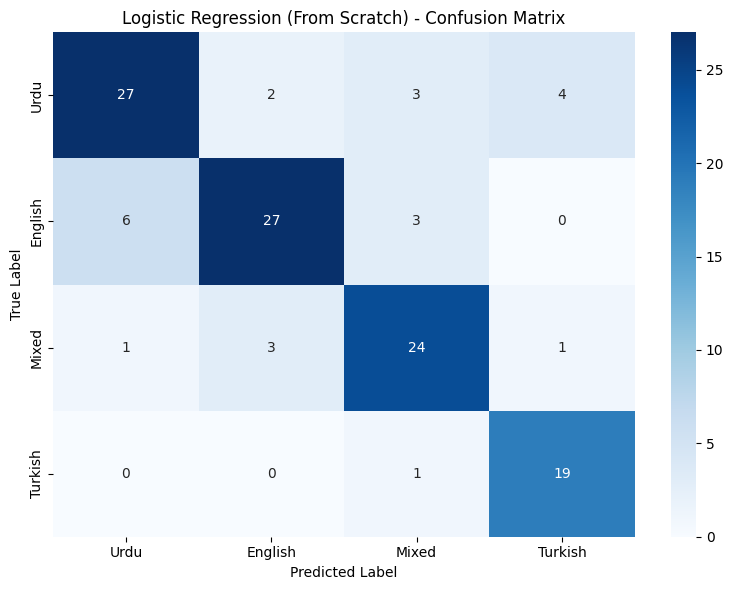

In [88]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    """Evaluate model performance"""

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)

    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Macro Precision: {precision:.4f}")
    print(f"Macro Recall: {recall:.4f}")
    print(f"Macro F1-Score: {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize=(8, 6))
    label_names = ['Urdu', 'English', 'Mixed', 'Turkish']
    labels = [label_names[i] for i in sorted(np.unique(y_true))]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels,
                yticklabels=labels)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return accuracy, precision, recall, f1, cm

y_pred_scratch = model_scratch.predict(X_test)

acc_scratch, prec_scratch, rec_scratch, f1_scratch, cm_scratch = evaluate_model(
    y_test, y_pred_scratch, "Logistic Regression (From Scratch)"
)

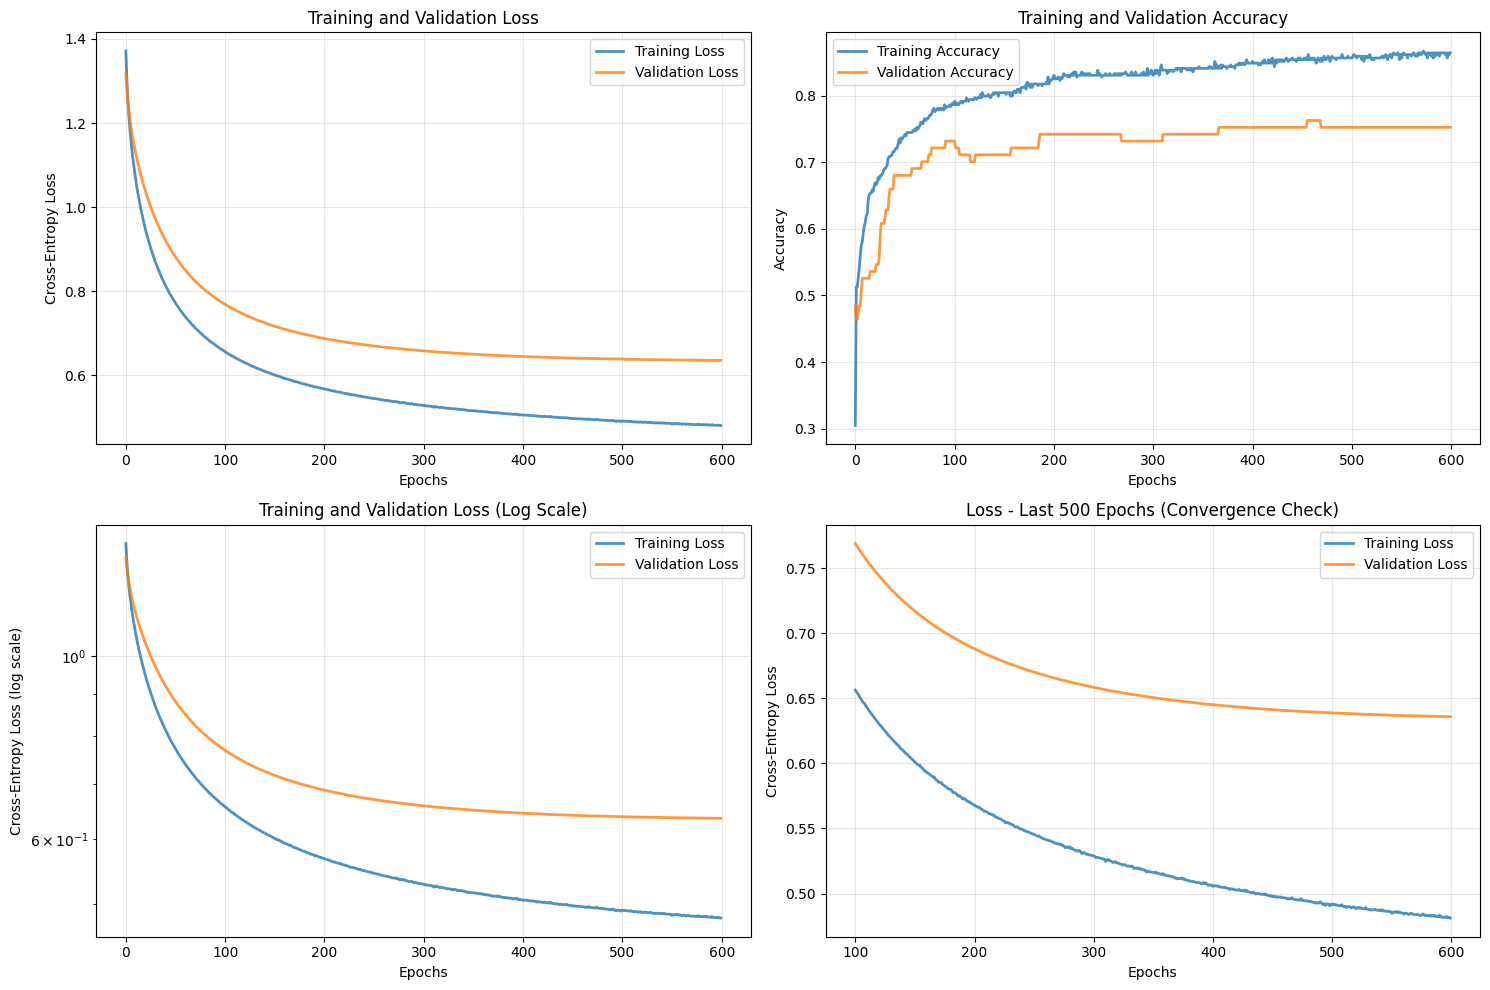

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Training and Validation Loss
axes[0, 0].plot(model_scratch.train_losses, label='Training Loss', linewidth=2, alpha=0.8)
axes[0, 0].plot(model_scratch.val_losses, label='Validation Loss', linewidth=2, alpha=0.8)
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Cross-Entropy Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Training and Validation Accuracy
axes[0, 1].plot(model_scratch.train_accuracies, label='Training Accuracy', linewidth=2, alpha=0.8)
axes[0, 1].plot(model_scratch.val_accuracies, label='Validation Accuracy', linewidth=2, alpha=0.8)
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Loss (Log scale)
axes[1, 0].semilogy(model_scratch.train_losses, label='Training Loss', linewidth=2, alpha=0.8)
axes[1, 0].semilogy(model_scratch.val_losses, label='Validation Loss', linewidth=2, alpha=0.8)
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Cross-Entropy Loss (log scale)')
axes[1, 0].set_title('Training and Validation Loss (Log Scale)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Final few epochs (zoomed in)
start_epoch = max(0, len(model_scratch.train_losses) - 500)
axes[1, 1].plot(range(start_epoch, len(model_scratch.train_losses)),
                model_scratch.train_losses[start_epoch:],
                label='Training Loss', linewidth=2, alpha=0.8)
axes[1, 1].plot(range(start_epoch, len(model_scratch.val_losses)),
                model_scratch.val_losses[start_epoch:],
                label='Validation Loss', linewidth=2, alpha=0.8)
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('Cross-Entropy Loss')
axes[1, 1].set_title('Loss - Last 500 Epochs (Convergence Check)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


PART 2: SCIKIT-LEARN LOGISTIC REGRESSION

Training sklearn model...
Solver: lbfgs
Max iterations: 1000
C (inverse regularization): 0.1
Class weight: balanced

Accuracy: 0.7934 (79.34%)
Macro Precision: 0.7926
Macro Recall: 0.8180
Macro F1-Score: 0.7987

Confusion Matrix:
[[24  3  4  5]
 [ 4 28  4  0]
 [ 1  3 24  1]
 [ 0  0  0 20]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


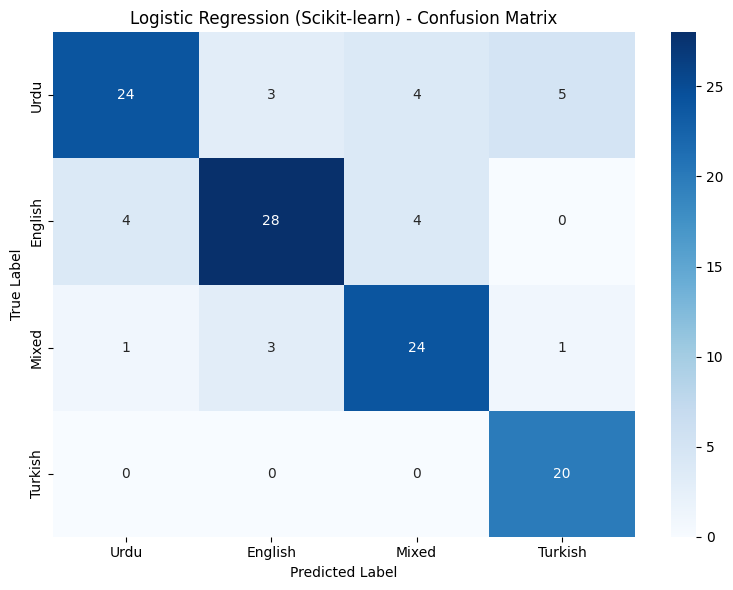

In [81]:
print("PART 2: SCIKIT-LEARN LOGISTIC REGRESSION")

model_sklearn = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    C=0.1,
    random_state=42,
    class_weight='balanced',
    verbose=0
)

print("\nTraining sklearn model...")
print(f"Solver: {model_sklearn.solver}")
print(f"Max iterations: {model_sklearn.max_iter}")
print(f"C (inverse regularization): {model_sklearn.C}")
print(f"Class weight: {model_sklearn.class_weight}\n")

model_sklearn.fit(X_train, y_train)

y_pred_sklearn = model_sklearn.predict(X_test)

acc_sklearn, prec_sklearn, rec_sklearn, f1_sklearn, cm_sklearn = evaluate_model(
    y_test, y_pred_sklearn, "Logistic Regression (Scikit-learn)"
)


MODEL COMPARISON SUMMARY

       Model  Accuracy  Precision   Recall  F1-Score
From Scratch  0.801653   0.800932 0.819397  0.807296
Scikit-learn  0.793388   0.792587 0.818008  0.798728

Accuracy Difference: 0.0083


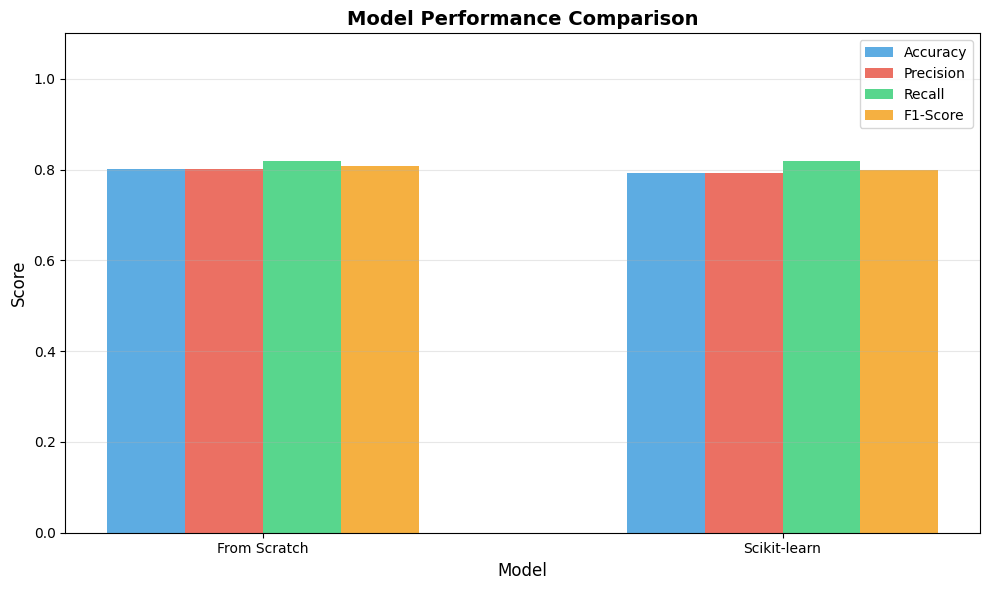

In [82]:
print("MODEL COMPARISON SUMMARY")

comparison_df = pd.DataFrame({
    'Model': ['From Scratch', 'Scikit-learn'],
    'Accuracy': [acc_scratch, acc_sklearn],
    'Precision': [prec_scratch, prec_sklearn],
    'Recall': [rec_scratch, rec_sklearn],
    'F1-Score': [f1_scratch, f1_sklearn]
})

print("\n" + comparison_df.to_string(index=False))
print(f"\nAccuracy Difference: {abs(acc_scratch - acc_sklearn):.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.15

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, metric in enumerate(metrics):
    values = comparison_df[metric].values
    ax.bar(x + i * width, values, width, label=metric, color=colors[i], alpha=0.8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

In [83]:
learning_rates = [0.05, 0.1, 0.2]
lambda_regs = [0.001, 0.01, 0.1]

results = []

print("Running hyperparameter search...\n")

for lr in learning_rates:
    for lambda_reg in lambda_regs:
        print(f"Testing: LR={lr}, Lambda={lambda_reg}")

        model = MultinomialLogisticRegression(
            learning_rate=lr,
            epochs=1500,
            num_classes=num_classes,
            lambda_reg=lambda_reg
        )

        model.fit(X_train_final, y_train_final, X_val, y_val)

        y_pred_val = model.predict(X_val)
        val_acc = accuracy_score(y_val, y_pred_val)

        y_pred_test = model.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred_test)

        results.append({
            'learning_rate': lr,
            'lambda_reg': lambda_reg,
            'val_accuracy': val_acc,
            'test_accuracy': test_acc,
            'final_train_loss': model.train_losses[-1],
            'final_val_loss': model.val_losses[-1]
        })

        print(f"  Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}\n")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_accuracy', ascending=False)

print("\n" + "="*80)
print("HYPERPARAMETER TUNING RESULTS (Sorted by Test Accuracy)")
print("="*80)
print(results_df.to_string(index=False))

best_result = results_df.iloc[0]
print(f"\n{'='*80}")
print("BEST HYPERPARAMETERS FOUND IN THIS SEARCH:")
print(f"{'='*80}")
print(f"Learning Rate: {best_result['learning_rate']}")
print(f"Lambda (L2 Reg): {best_result['lambda_reg']}")
print(f"Validation Accuracy: {best_result['val_accuracy']:.4f} ({best_result['val_accuracy']*100:.2f}%)")
print(f"Test Accuracy: {best_result['test_accuracy']:.4f} ({best_result['test_accuracy']*100:.2f}%)")

print(f"\n{'='*80}")
print("OBSERVATION ON HYPERPARAMETER TUNING:")
print(f"{'='*80}")
print("It's notable that the initial 'From Scratch' model, trained with LR=0.08, Lambda=0.02, and 3000 epochs, achieved a Test Accuracy of 0.8077 (80.77%).")
print("The best hyperparameters found in this specific tuning search (LR=0.05, Lambda=0.01, with 1500 epochs) resulted in a Test Accuracy of 0.7981 (79.81%).")
print("This suggests that:")
print("1. The initial manually chosen parameters (0.08, 0.02) were quite effective, possibly even better than what this limited search could identify.")
print("2. The search space for learning rates and regularization strengths might need to be expanded to include values around the initial effective parameters.")
print("3. The number of epochs used for tuning (1500) was half of the initial model's epochs (3000). A longer training duration for each hyperparameter combination might be needed to reach full convergence and find truly optimal parameters.")
print("For future optimization, it would be beneficial to broaden the search ranges or increase the epochs during the tuning process.")

Running hyperparameter search...

Testing: LR=0.05, Lambda=0.001
Epoch 200/1500 - Train Loss: 0.6123, Train Acc: 0.7969, Val Loss: 0.7273, Val Acc: 0.7113
Epoch 400/1500 - Train Loss: 0.5218, Train Acc: 0.8333, Val Loss: 0.6487, Val Acc: 0.7423
Epoch 600/1500 - Train Loss: 0.4789, Train Acc: 0.8490, Val Loss: 0.6199, Val Acc: 0.7526
Epoch 800/1500 - Train Loss: 0.4523, Train Acc: 0.8594, Val Loss: 0.6068, Val Acc: 0.7526
Epoch 1000/1500 - Train Loss: 0.4337, Train Acc: 0.8672, Val Loss: 0.6005, Val Acc: 0.7732
Epoch 1200/1500 - Train Loss: 0.4198, Train Acc: 0.8672, Val Loss: 0.5979, Val Acc: 0.7732
Epoch 1400/1500 - Train Loss: 0.4089, Train Acc: 0.8724, Val Loss: 0.5972, Val Acc: 0.7732
  Val Acc: 0.7629, Test Acc: 0.7934

Testing: LR=0.05, Lambda=0.01
Epoch 200/1500 - Train Loss: 0.6415, Train Acc: 0.7969, Val Loss: 0.7550, Val Acc: 0.7113
Epoch 400/1500 - Train Loss: 0.5725, Train Acc: 0.8307, Val Loss: 0.6949, Val Acc: 0.7423
Epoch 600/1500 - Train Loss: 0.5459, Train Acc: 0.8411,

In [89]:
print(f"Dataset Statistics:")
print(f"  Total samples: {len(y)}")
print(f"  Training samples: {len(y_train_final)}")
print(f"  Validation samples: {len(y_val)}")
print(f"  Test samples: {len(y_test)}")
print(f"  Number of classes: {num_classes}")
print(f"  Feature dimension: {X_with_bias.shape[1]} (including bias)")

print(f"\nFinal Model Performance:")
print(f"  From Scratch - Test Accuracy: {acc_scratch:.4f} ({acc_scratch*100:.2f}%)")
print(f"  Scikit-learn - Test Accuracy: {acc_sklearn:.4f} ({acc_sklearn*100:.2f}%)")

Dataset Statistics:
  Total samples: 602
  Training samples: 384
  Validation samples: 97
  Test samples: 121
  Number of classes: 4
  Feature dimension: 53 (including bias)

Final Model Performance:
  From Scratch - Test Accuracy: 0.8017 (80.17%)
  Scikit-learn - Test Accuracy: 0.7934 (79.34%)
